# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

In [2]:
import pandas as pd 
import numpy as np

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams['text.usetex'] = False

In [4]:
from core.variables import * 
from core.estimators import *
from core.dgp import *
from core.experiments import *
from core.visualization import *

# Group Targeting

In [5]:
sample_size_df = pd.read_csv('results/sample_size_test.csv')
# get estimators 
estimators = [col[:-4] for col in sample_size_df.columns if '_est' in col]

# calculate winner's curse
for estimator in estimators:
    sample_size_df[f'{estimator}_wc'] = sample_size_df[f"{estimator}_est"] - sample_size_df['act_plugin_val']

# clean unnecessary columns
wc_columns = [f'{estimator}_wc' for estimator in estimators]
sample_size_df = sample_size_df[['sample_size'] + wc_columns + ['test_group_id', 'repeat_id']]

In [6]:
sample_size_df[sample_size_df['sample_size'] == 100].describe()

,sample_size,plugin_wc,error_correction_wc,mnb_error_correction_wc,nb_error_correction_wc,value_correction_wc,mnb_value_correction_wc,nb_value_correction_wc,test_group_id,repeat_id
count,625.0,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000,625.000000
mean,100.0,0.158321,0.050465,0.010293,0.025024,0.049840,0.012126,0.025212,12.000000,12.000000
std,0.0,0.244359,0.272184,0.273097,0.274040,0.272339,0.274379,0.273996,7.216878,7.216878
min,100.0,-0.645789,-0.772757,-0.812452,-0.800063,-0.772055,-0.785266,-0.801978,0.000000,0.000000
25%,100.0,-0.013032,-0.145923,-0.184121,-0.170312,-0.145226,-0.187831,-0.167631,6.000000,6.000000
50%,100.0,0.153339,0.030331,-0.009328,0.007088,0.029533,-0.009993,0.010283,12.000000,12.000000
75%,100.0,0.315194,0.235725,0.189862,0.210918,0.237270,0.185515,0.211801,18.000000,18.000000
max,100.0,1.081421,1.079425,1.071063,1.102090,1.089141,1.049386,1.085940,24.000000,24.000000


Fixed Knobs:  sample_size: 100, num_bootstrap: 500.0, noise_std: 1.0, te_diff: 0.1, 

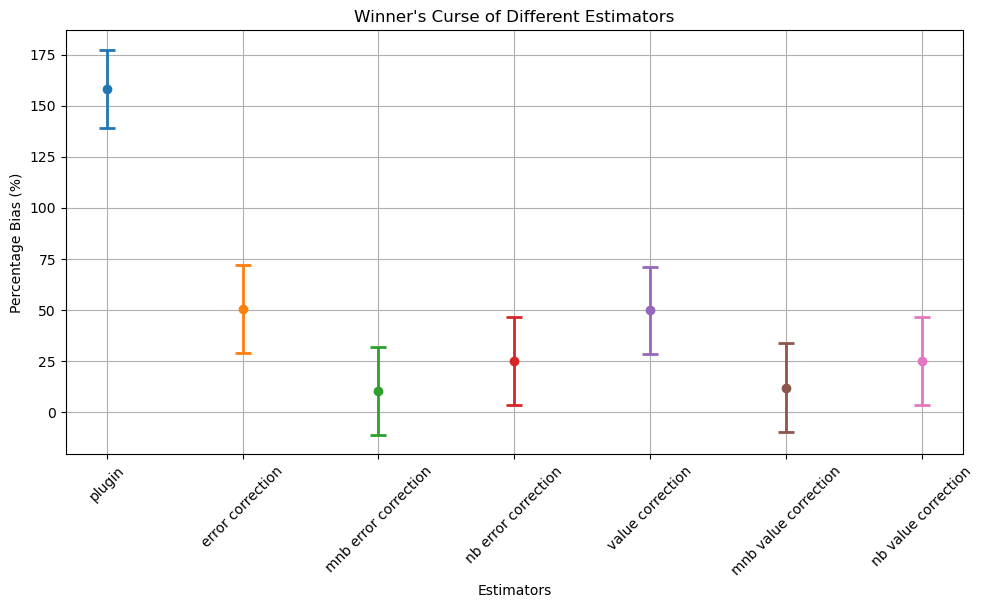

In [7]:
plot_winners_curse_errorbar('results/sample_size_test.csv', sample_size=100, unit_basis=0.1, confidence_level=0.95)

Fixed Knobs:  sample_size: 1000.0, num_bootstrap: 200.0, noise_std: 1.0, 

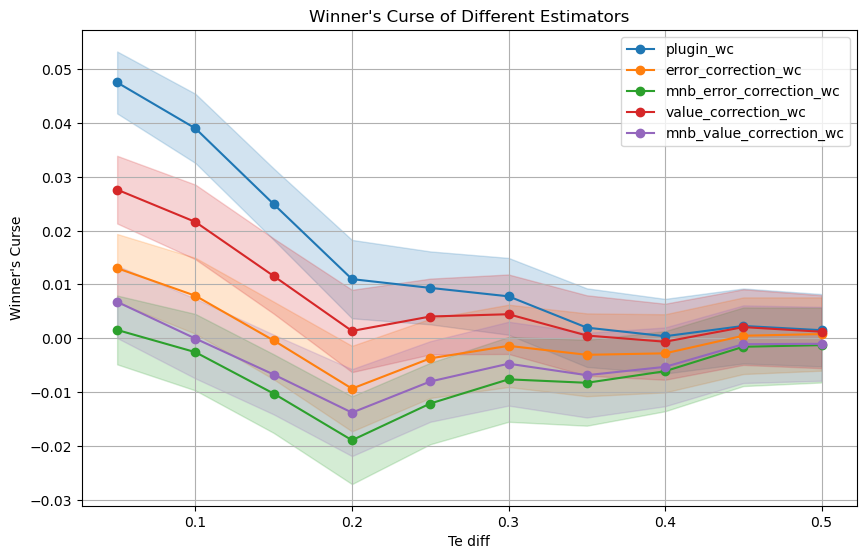

In [8]:
plot_winners_curse_2d(
    'results/te_diff_test.csv', 
    x='te_diff', confidence_level=0.95, 
)

Fixed Knobs:  sample_size: 1000.0, num_bootstrap: 200.0, te_diff: 0.1, 

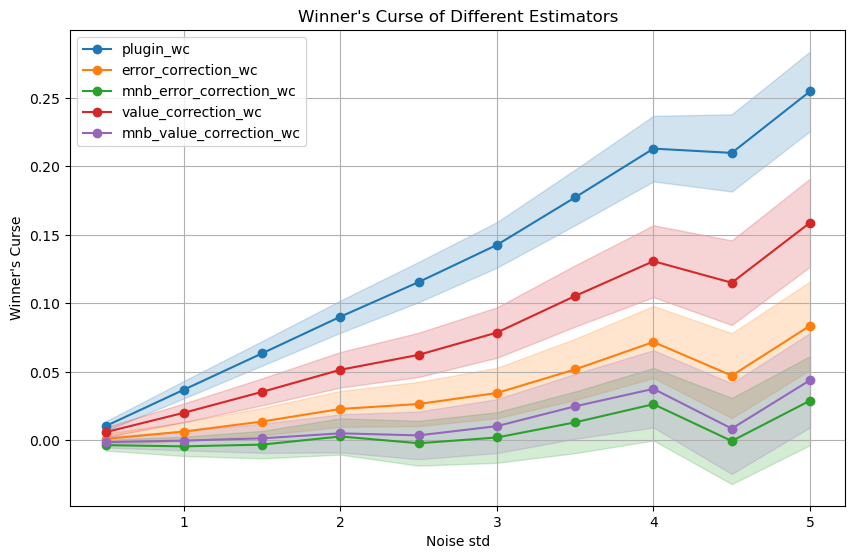

In [9]:
plot_winners_curse_2d(
    'results/noise_std_test.csv', 
    x='noise_std', confidence_level=0.95, 
)

# Price Targeting